# ResNet-101

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                                kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

In [5]:
class ResNet101(nn.Module):

    layers_per_stage = [3, 4, 23, 3]
    stage_channels = [64, 128, 256, 512]

    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.stage1 = self._make_stage(64, self.layers_per_stage[0], stride=1)
        self.stage2 = self._make_stage(128, self.layers_per_stage[1], stride=2)
        self.stage3 = self._make_stage(256, self.layers_per_stage[2], stride=2)
        self.stage4 = self._make_stage(512, self.layers_per_stage[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

        self._initialize_weights()

    def _make_stage(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(Bottleneck(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels * Bottleneck.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.fc(x)

model = ResNet101(num_classes=10).to(device)
print(model)

ResNet101(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (stage1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequen

In [6]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [7]:
def count_conv_params(in_ch, out_ch, kernel_size):
    return kernel_size * kernel_size * in_ch * out_ch

def count_bn_params(num_features):
    return 2 * num_features

resnet50_blocks = sum([3, 4, 6, 3])
resnet101_blocks = sum(model.layers_per_stage)
print(f"ResNet-50 blocks: {resnet50_blocks}")
print(f"ResNet-101 blocks: {resnet101_blocks}")
print(f"Extra blocks, all in stage 3: {resnet101_blocks - resnet50_blocks}")


in_ch, out_ch = 256, 64
conv1 = count_conv_params(in_ch, out_ch, 1)
bn1 = count_bn_params(out_ch)
conv2 = count_conv_params(out_ch, out_ch, 3)
bn2 = count_bn_params(out_ch)
conv3 = count_conv_params(out_ch, out_ch * 4, 1)
bn3 = count_bn_params(out_ch * 4)

block_manual = conv1 + bn1 + conv2 + bn2 + conv3 + bn3
block_torch = sum(p.numel() for p in model.stage1[1].parameters())

print(f"\nBottleneck manual total: {block_manual:,}")
print(f"Bottleneck torch total:  {block_torch:,}")
assert block_manual == block_torch, "Mismatch in Bottleneck parameter count"

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal ResNet-101 parameters: {total_params:,}")

ResNet-50 blocks: 16
ResNet-101 blocks: 33
Extra blocks, all in stage 3: 17

Bottleneck manual total: 70,400
Bottleneck torch total:  70,400

Total ResNet-101 parameters: 42,520,650


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [10]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.1308 train_acc=0.2245 | val_loss=2.3602 val_acc=0.2492 | time=207.8s
Epoch 2/10 | train_loss=1.9274 train_acc=0.3237 | val_loss=1.8188 val_acc=0.3646 | time=201.9s
Epoch 3/10 | train_loss=1.7954 train_acc=0.3819 | val_loss=1.7175 val_acc=0.4158 | time=202.5s
Epoch 4/10 | train_loss=1.6929 train_acc=0.4225 | val_loss=1.5865 val_acc=0.4711 | time=201.5s
Epoch 5/10 | train_loss=1.5995 train_acc=0.4626 | val_loss=1.6001 val_acc=0.4772 | time=201.5s
Epoch 6/10 | train_loss=1.5015 train_acc=0.4956 | val_loss=1.5197 val_acc=0.5098 | time=201.6s
Epoch 7/10 | train_loss=1.4235 train_acc=0.5288 | val_loss=1.3025 val_acc=0.5755 | time=202.2s
Epoch 8/10 | train_loss=1.3676 train_acc=0.5467 | val_loss=1.2318 val_acc=0.5908 | time=201.3s
Epoch 9/10 | train_loss=1.2798 train_acc=0.5738 | val_loss=1.1485 val_acc=0.6306 | time=203.9s
Epoch 10/10 | train_loss=1.2283 train_acc=0.5950 | val_loss=1.0860 val_acc=0.6441 | time=203.7s


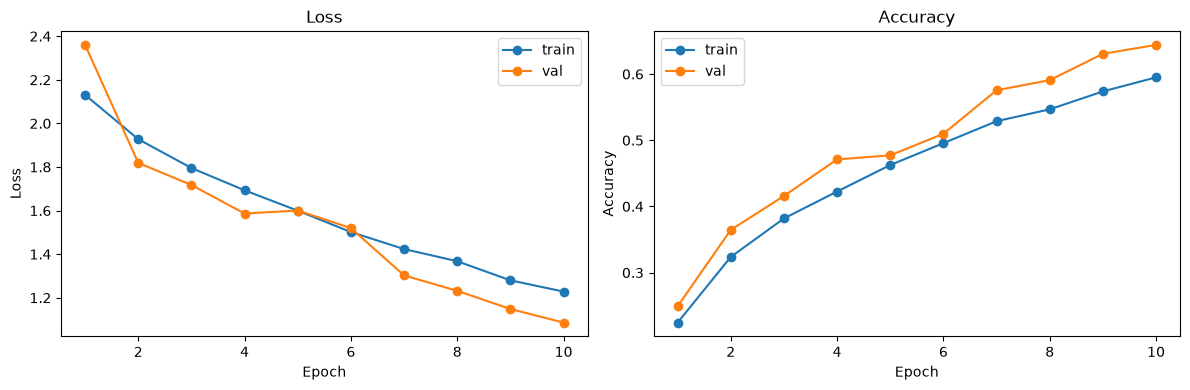

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

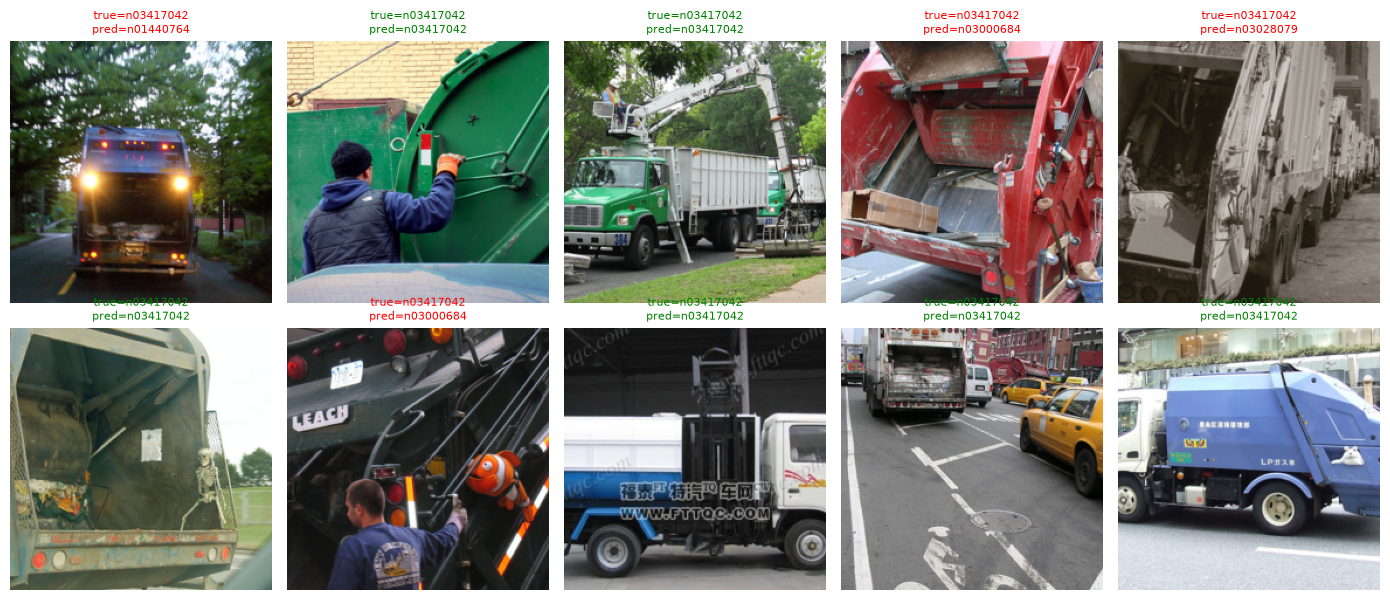

In [12]:
model.eval()

random_batch_idx = random.randint(0, len(val_loader) - 1)
for i, batch in enumerate(val_loader):
    if i == random_batch_idx:
        sample_images, sample_labels = batch
        break

class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: see output above.
ResNet-101 reuses the exact same Bottleneck block as ResNet-50; the extra
depth (101 vs 50 weight layers) comes entirely from deepening stage 3
(23 blocks instead of 6), while stages 1, 2, and 4 are unchanged.

**Why Adam instead of SGD with momentum.** The original paper used SGD with
momentum=0.9, weight decay 0.0001, and a step learning rate schedule. We
used Adam for simpler, more reliable convergence without manual tuning.